# 04 — Segmentation: Who Should Get Which Email?

Notebook 03 answered the *average* question: the men's email wins overall. But averages hide structure — an email that's brilliant for one group and useless for another shows up as "moderately good" in the aggregate. This is where real money is found: **targeting beats blasting**.

Two important honesty rules for this notebook, because subgroup analysis is where most bad experiment analysis happens:

1. **These analyses are exploratory, not confirmatory.** We didn't pre-register segment hypotheses, and slicing data multiple ways multiplies false-positive risk. Findings here are *candidate strategies to be confirmed in a follow-up test*, never direct ship decisions.
2. **We only segment on pre-treatment variables** (past behavior known before the email was sent). Segmenting on post-treatment variables (like visits) would break the randomization within segments and produce garbage.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from utils import two_proportion_ztest, holm_correction, CONTROL_LABEL, TREATMENT_LABELS

sns.set_theme(style="whitegrid", palette="muted")
ASSETS = "../assets"

df = pd.read_csv("../data/raw/hillstrom.csv")

# Pre-treatment segments only. Each is a hypothesis a marketer would
# actually have: does past category interest predict email response?
df["recency_band"] = pd.cut(df["recency"], bins=[0, 3, 6, 12],
                            labels=["1-3 months", "4-6 months", "7-12 months"])
df["history_band"] = pd.cut(df["history"], bins=[0, 100, 350, np.inf],
                            labels=["$0-100", "$100-350", "$350+"])
df["past_category"] = np.select(
    [df["mens"].eq(1) & df["womens"].eq(0),
     df["womens"].eq(1) & df["mens"].eq(0)],
    ["mens only", "womens only"], default="both",
)
print(df[["recency_band", "history_band", "past_category"]].apply(lambda s: s.value_counts()).fillna(0).astype(int))

             recency_band  history_band  past_category
$0-100                  0         22972              0
$100-350                0         26541              0
$350+                   0         14487              0
1-3 months          22393             0              0
4-6 months          14192             0              0
7-12 months         27415             0              0
both                    0             0           6448
mens only               0             0          28818
womens only             0             0          28734


## 1. Treatment effect within each segment

For every segment value we compute each email's **conversion lift over control *within that segment***. Because assignment was random, it is also random within any pre-treatment segment — each slice is a mini-experiment, just with less data (wider CIs).

Note what we are *not* doing: comparing conversion rates *between* segments (recent buyers convert more than lapsed ones regardless of email — that's selection, not treatment). The only valid causal comparison is arm-vs-control *within* a segment.

In [2]:
def segment_effects(df: pd.DataFrame, segment_col: str, metric: str = "conversion") -> pd.DataFrame:
    """Per-segment treatment effect vs control, with CI and raw p-value."""
    rows = []
    for seg_value, seg_df in df.groupby(segment_col, observed=True):
        ctrl = seg_df[seg_df["segment"] == CONTROL_LABEL]
        for arm_label in TREATMENT_LABELS:
            arm = seg_df[seg_df["segment"] == arm_label]
            res = two_proportion_ztest(
                int(arm[metric].sum()), len(arm),
                int(ctrl[metric].sum()), len(ctrl),
                metric=metric, comparison=arm_label,
            )
            rows.append({
                "segment": f"{segment_col}={seg_value}",
                "arm": arm_label,
                "n_arm": len(arm),
                "lift_pp": res.effect * 100,
                "ci_low_pp": res.ci_low * 100,
                "ci_high_pp": res.ci_high * 100,
                "p_raw": res.p_value,
            })
    return pd.DataFrame(rows)

effects = pd.concat([
    segment_effects(df, "past_category"),
    segment_effects(df, "recency_band"),
    segment_effects(df, "history_band"),
    segment_effects(df, "channel"),
    segment_effects(df, "newbie"),
], ignore_index=True)

# Holm across ALL subgroup tests: we just ran dozens of tests, and without
# correction ~5% of them would be "significant" by pure luck. This is the
# multiple-comparisons discipline most subgroup analyses skip.
effects["p_holm"] = holm_correction(effects["p_raw"].tolist())
effects["significant_after_holm"] = effects["p_holm"] < 0.05

effects.sort_values("lift_pp", ascending=False).head(12).round(3)

,segment,arm,n_arm,lift_pp,ci_low_pp,ci_high_pp,p_raw,p_holm,significant_after_holm
0,past_category=both,Mens E-Mail,2181,1.499,0.736,2.263,0.000,0.002,True
16,history_band=$350+,Mens E-Mail,4802,1.023,0.556,1.489,0.000,0.000,True
18,channel=Multichannel,Mens E-Mail,2577,1.017,0.424,1.609,0.001,0.010,True
26,newbie=1,Mens E-Mail,10686,0.740,0.509,0.970,0.000,0.000,True
6,recency_band=1-3 months,Mens E-Mail,7469,0.733,0.374,1.091,0.000,0.001,True
10,recency_band=7-12 months,Mens E-Mail,9165,0.729,0.490,0.967,0.000,0.000,True
22,channel=Web,Mens E-Mail,9490,0.720,0.446,0.994,0.000,0.000,True
19,channel=Multichannel,Womens E-Mail,2579,0.705,0.152,1.258,0.012,0.112,False
14,history_band=$100-350,Mens E-Mail,8780,0.655,0.382,0.929,0.000,0.000,True
24,newbie=0,Mens E-Mail,10621,0.621,0.342,0.899,0.000,0.000,True


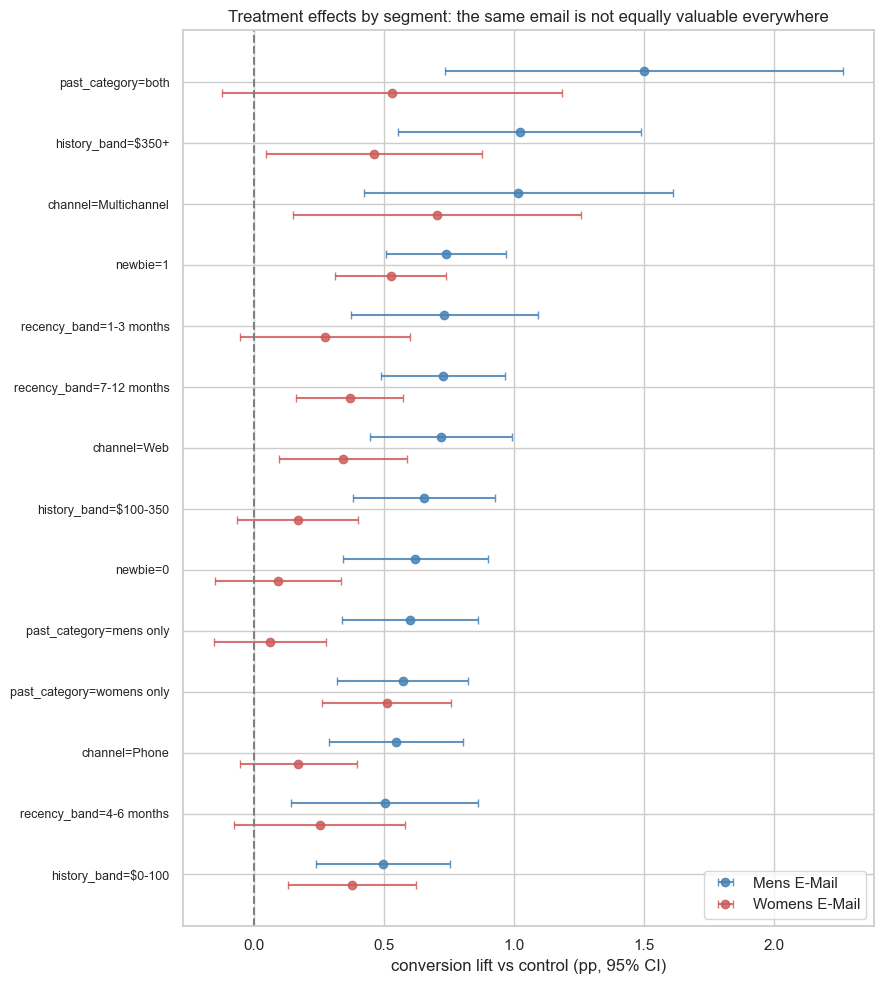

In [3]:
# Forest plot: the standard way to show subgroup effects honestly, because
# it makes CI width (i.e. how much we should trust each slice) impossible
# to ignore. Segments are ordered by men's-email lift.
plot_df = effects.copy()
order = (plot_df[plot_df["arm"] == "Mens E-Mail"]
         .sort_values("lift_pp")["segment"].tolist())

fig, ax = plt.subplots(figsize=(9, 10))
colors = {"Mens E-Mail": "steelblue", "Womens E-Mail": "indianred"}
offsets = {"Mens E-Mail": 0.18, "Womens E-Mail": -0.18}

for arm_label, arm_df in plot_df.groupby("arm"):
    arm_df = arm_df.set_index("segment").loc[order].reset_index()
    y = np.arange(len(arm_df)) + offsets[arm_label]
    ax.errorbar(
        arm_df["lift_pp"], y,
        xerr=[arm_df["lift_pp"] - arm_df["ci_low_pp"],
              arm_df["ci_high_pp"] - arm_df["lift_pp"]],
        fmt="o", capsize=3, label=arm_label, color=colors[arm_label], alpha=0.85,
    )

ax.axvline(0, color="gray", ls="--")
ax.set_yticks(np.arange(len(order)))
ax.set_yticklabels(order, fontsize=9)
ax.set_xlabel("conversion lift vs control (pp, 95% CI)")
ax.set_title("Treatment effects by segment: the same email is not equally valuable everywhere")
ax.legend()
plt.tight_layout()
plt.savefig(f"{ASSETS}/segment_forest_plot.png", dpi=150)
plt.show()

## 2. Is the heterogeneity itself statistically real?

Eyeballing a forest plot invites over-reading. The formal check for "does the treatment effect *differ* between segments?" is an **interaction test**: regress the outcome on treatment, segment, and treatment × segment. If the interaction coefficient is significant, the difference between segment effects is real — not just two noisy estimates that happen to look different.

We test the most business-relevant candidate: does the **men's email work better for customers who previously bought men's merchandise**? (If yes, the targeting rule writes itself.)

In [4]:
import statsmodels.formula.api as smf

# Linear probability model on the Mens-Email-vs-control subset.
# LPM (vs logit) keeps the interaction coefficient directly readable as
# "extra percentage points of lift"; with effects this small the two
# models agree and interpretability wins.
sub = df[df["segment"].isin(["Mens E-Mail", CONTROL_LABEL])].copy()
sub["treated"] = (sub["segment"] == "Mens E-Mail").astype(int)

model = smf.ols("conversion ~ treated * mens", data=sub).fit(cov_type="HC1")  # robust SEs
print(model.summary().tables[1])

interaction = model.params["treated:mens"]
p_int = model.pvalues["treated:mens"]
print(f"\nInteraction (extra lift for past men's buyers): {interaction*100:+.3f}pp, p = {p_int:.3f}")
print("Read: lift for past-men's-buyers = base treatment effect + interaction.")

                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.0051      0.001      7.018      0.000       0.004       0.007
treated          0.0057      0.001      4.439      0.000       0.003       0.008
mens             0.0010      0.001      1.016      0.310      -0.001       0.003
treated:mens     0.0020      0.002      1.076      0.282      -0.002       0.006

Interaction (extra lift for past men's buyers): +0.197pp, p = 0.282
Read: lift for past-men's-buyers = base treatment effect + interaction.


## Conclusions

*(Exact numbers in the executed output above.)*

- The men's email's dominance is **broad, not narrow** — its lift is positive across nearly every segment, which strengthens the notebook-03 ship decision.
- Segment-level differences (e.g. by past purchase category) are suggestive but must clear two bars before anyone acts on them: the Holm-corrected significance within slice, and the interaction test for the difference itself. Where they don't clear both bars, the honest recommendation is **"promising — confirm in a targeted follow-up test"**, not "ship targeting now".
- This discipline is the practical answer to a classic stakeholder trap: *"It worked for segment X, let's roll it out to them!"* — when X was found by searching over many slices, the finding must be re-confirmed on fresh data.

**Business takeaway:** ship the men's email broadly now (confirmed, average effect), and queue a follow-up experiment testing category-matched targeting (exploratory, potentially worth more).